In [2]:
# For data manipulation and visualization
import pandas as pd
import altair as alt

In [3]:
folder = '/content/drive/MyDrive/Academico/Métodos Estatísticos/2026/Aula 4 - Prática de dados categóricos'

# Exemplos resolvidos do livro-texto

## Exemplo 1.2 (p. 13) - Qual área de estudo?

Cerca de 1,5 milhão de estudantes se matricularam em faculdades e universidades em 2017.

Aqui estão dados sobre o percentual de estudantes de primeiro ano que pretendiam se habilitar em diversas áreas disciplinares:

In [3]:
areaestudo = pd.read_excel('eg01-02majors.xls')

In [4]:
areaestudo

,Field of Study,Percent
0,ArtsHumanities,8.8
1,BiologicalSciences,15.5
2,Business,13.8
3,Education,4.4
4,Engineering,11.5
5,HealthProf,11.7
6,MathComp,6.2
7,PhysicalSciences,2.7
8,Social Sciences,11.0
9,Other,13.1


É uma boa ideia verificar a consistência desses dados. Os percentuais devem totalizar 100%. Se isso não acontecer, ou houve um **erro de arredondamento ou um erro nos dados**.

In [5]:
areaestudo.shape

(10, 2)

In [6]:
areaestudo.Percent.sum()

np.float64(98.69999999999999)

In [7]:
areaestudo.loc[9,'Percent'] = (areaestudo.loc[9,'Percent']) + 100-areaestudo.Percent.sum()

In [8]:
areaestudo

,Field of Study,Percent
0,ArtsHumanities,8.8
1,BiologicalSciences,15.5
2,Business,13.8
3,Education,4.4
4,Engineering,11.5
5,HealthProf,11.7
6,MathComp,6.2
7,PhysicalSciences,2.7
8,Social Sciences,11.0
9,Other,14.4


In [9]:
areaestudo.Percent.sum()

np.float64(100.0)

### Gráfico de setores

#### Com o plot padrão do pandas

<Axes: ylabel='Percent'>

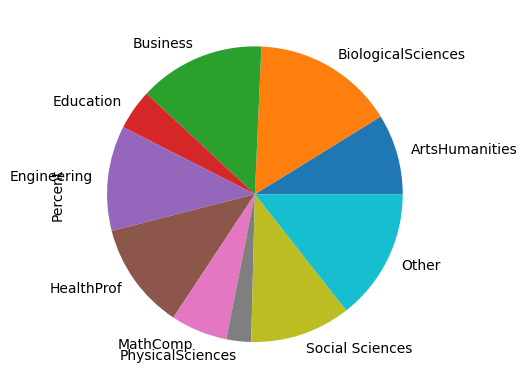

In [10]:
areaestudo.set_index('Field of Study').Percent.plot.pie()

#### Com Altair

In [11]:
alt.Chart(areaestudo).mark_arc().encode(
    theta = "Percent",
    color = alt.Color('Field of Study'),
    tooltip = ['Field of Study:N', 'Percent:Q']
)

alt.Chart(...)

In [12]:
# Creating a base chart with a title, aligned to the left and with normal font weight
base = alt.Chart(
    areaestudo,
    title = alt.TitleParams(r"Habilitação", anchor = 'start', fontWeight = 'normal')
).encode(
    theta = alt.Theta("Percent:Q", stack = True), # Encoding the angle (theta) for the pie chart
    color = alt.Color('Field of Study', legend = None), # Encoding color based on the 'Field of Study' field
    #order = alt.Order(field = 'Discipĺina') # Ordering the sectors of the pie chart based on the 'Field of Study' field
)

# Creating the pie chart with an outer radius of 115
pie = base.mark_arc(outerRadius = 115)

# Creating text labels for each sector of the pie chart
text = base.mark_text(radius = 150, size = 15).encode(text = alt.Text("Field of Study"))

# Combining the pie chart and text labels
acc_pie = pie + text
acc_pie

alt.LayerChart(...)

In [13]:
# Creating a base chart with a title, aligned to the left and with normal font weight
alt.Chart(
    areaestudo
).mark_arc(outerRadius = 115).encode(
    theta = alt.Theta("Percent:Q", stack = True), # Encoding the angle (theta) for the pie chart
    color = alt.Color('Field of Study', legend = None), # Encoding color based on the 'Field of Study' field
    #order = alt.Order(field = 'Discipĺina') # Ordering the sectors of the pie chart based on the 'Field of Study' field
    tooltip = ['Field of Study:N', 'Percent:Q']
)

alt.Chart(...)

### Gráfico de barras

#### Com o plot padrão do pandas

<Axes: xlabel='Field of Study'>

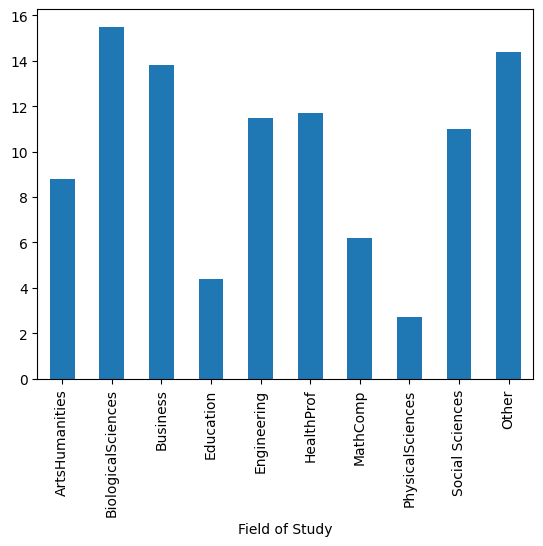

In [14]:
areaestudo.set_index('Field of Study').Percent.plot.bar()

#### Com Altair

In [15]:
alt.Chart(areaestudo).mark_bar().encode(
    x=alt.X("Field of Study:N", axis=alt.Axis(labelAngle=-45), sort=None),
    y="Percent:Q"
)

alt.Chart(...)

In [16]:
# Creating a vertical bar chart
vert_bar = alt.Chart(
    areaestudo,
    title = alt.TitleParams('Habilitação', fontSize = 20, anchor='start')  # Adding a title with specific font size
).mark_bar().encode(
    y = alt.Y(
        'Percent:Q',
        axis = alt.Axis(
            title = "% de estudantes que pretendem uma habilitação",  # Setting a custom title for the y-axis
            titleAlign = 'left',  # Aligning the title to the left
            titleAngle = 0,  # Setting the title angle to 0 degrees
            titleAnchor = 'end',  # Anchoring the title to the end
            titleY = -10,  # Adjusting the title position
            grid = False,  # Turning off grid lines
            labelColor = "#888888",  # Setting the label color to gray
            titleColor = '#888888'  # Setting the title color to gray
        )
    ),
    x = alt.X(
        'Field of Study:N',
        axis=alt.Axis(labelAngle=-45, ticks = False),
        sort=None
    )
).properties(
    width = 500  # Setting the width of the chart
).configure_view(stroke = None).configure_scale(bandPaddingInner=0.4)

vert_bar

alt.Chart(...)

In [17]:
# Creating a vertical bar chart
vert_bar = alt.Chart(
    areaestudo,
    title = alt.TitleParams('Habilitação', fontSize = 20, anchor='start')  # Adding a title with specific font size
).mark_bar().encode(
    y = alt.Y(
        'Percent:Q',
        axis = alt.Axis(
            title = "% de estudantes que pretendem uma habilitação",  # Setting a custom title for the y-axis
            titleAlign = 'left',  # Aligning the title to the left
            titleAngle = 0,  # Setting the title angle to 0 degrees
            titleAnchor = 'end',  # Anchoring the title to the end
            titleY = -10,  # Adjusting the title position
            grid = False,  # Turning off grid lines
            labelColor = "#888888",  # Setting the label color to gray
            titleColor = '#888888'  # Setting the title color to gray
        )
    ),
    x = alt.X(
        'Field of Study:N',
        axis=alt.Axis(labelAngle=-45, ticks = False),
        sort='-y'
    )
).properties(
    width = 500  # Setting the width of the chart
).configure_view(stroke = None).configure_scale(bandPaddingInner=0.4)

vert_bar

alt.Chart(...)

## Aplique seu conhecimento 1.3 (p. 15) - Preferências por mídias sociais para audiências mais jovens

Por uma pequena margem, Facebook permanece a escolha principal de mídia social em todas as idades, com 29% usando o Facebook com mais frequência entre os que usam mídias sociais. No entanto, as redes sociais mais visualmente orientadas, como Snapchat e Instagram, continuam a penetrar nas audiências mais jovens.

Quando se pergunta “Qual plataforma de rede social você usa com mais frequência?”, eis as plataformas mais usadas pelos americanos de 12 a 34 anos que usam atualmente algum serviço ou site de rede social:

In [18]:
midiassociais = pd.read_excel(f'ex01-03socmedia.xls')

In [19]:
midiassociais

,Social Media Site,Percentage
0,Facebook,29
1,Snapchat,28
2,Instagram,26
3,Twitter,6
4,Pinterest,1


a. Qual é a soma das porcentagens para esses sites principais de mídias sociais? Qual o percentual de americanos com idade de 12 a 34 anos que usam outros sites de mídia social com mais frequência?

In [20]:
midiassociais.Percentage.sum()

np.int64(90)

In [21]:
100-midiassociais.Percentage.sum()

np.int64(10)

c. Seria correto apresentar esses dados em um gráfico de setores? Por que ou por que não?

b. Faça um gráfico de barras para apresentar esses dados. Certifique-se de incluir uma categoria "Outra plataforma de mídia social".

In [22]:
midiassociais.loc[5] = ['Outras', 100-midiassociais.Percentage.sum()]

In [23]:
midiassociais

,Social Media Site,Percentage
0,Facebook,29
1,Snapchat,28
2,Instagram,26
3,Twitter,6
4,Pinterest,1
5,Outras,10


In [24]:
midiassociais.Percentage.sum()

np.int64(100)

#### Com o plot padrão do pandas

<Axes: xlabel='Social Media Site'>

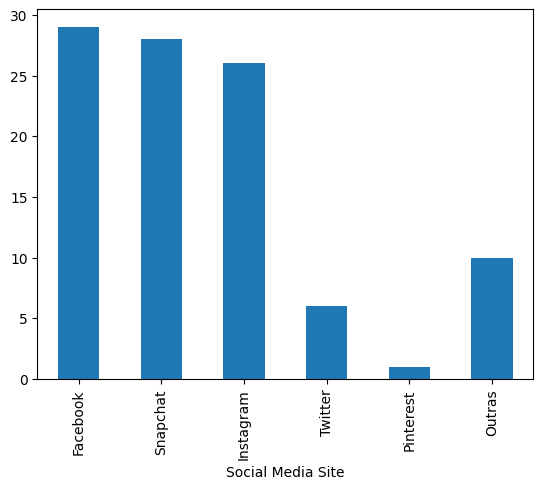

In [25]:
midiassociais.set_index('Social Media Site').Percentage.plot.bar()

#### Com Altair

In [26]:
# Creating a vertical bar chart
vert_bar = alt.Chart(
    midiassociais,
    # title = alt.TitleParams('Preferências por mídias sociais para audiências mais jovens', fontSize = 20, anchor='start')  # Adding a title with specific font size
).mark_bar().encode(
    x = alt.X(
        'Percentage:Q',
        axis = alt.Axis(
            title = "% de jovens americanos que usam preferencialmente a plataforma",  # Setting a custom title for the y-axis
            grid = True,  # Turning off grid lines
        )
    ),
    y = alt.Y(
        'Social Media Site:N',
        axis=alt.Axis(labelAngle=0, ticks = False),
        sort='-x'
    )
).properties(
    height=400,width = 500  # Setting the width of the chart
).configure_view(stroke = None).configure_scale(bandPaddingInner=0.3)

vert_bar

alt.Chart(...)

# Aplicação com bases dos casos

## Base bebês de Bristol

Refaça as análises do caso explorando as possibilidade de enquadramento positivo e negativo, e escolhas de comunicação.

- Replique com Altair os gráficos apresentados no caso.
- Teste como o gráfico de taxa de sobrevivência ficaria com mudanças na escala do eixo horizontal.
- Pense em pequenas mudanças nessas visualizações. Você daria destaque a alguma informação para comunicar algo que julga importante?

In [28]:
child_heart = pd.read_csv(f'01-1-child-heart-survival-x.csv')

In [29]:
child_heart

,Hospital,Operations,Survivors,Deaths,ThirtyDaySurvival,PercentageDying
0,London - Harley Street,418,413,5,98.8,1.2
1,Leicester,607,593,14,97.7,2.3
2,Newcastle,668,653,15,97.8,2.2
3,Glasgow,760,733,27,96.3,3.7
4,Southampton,829,815,14,98.3,1.7
5,Bristol,835,821,14,98.3,1.7
6,Dublin,983,960,23,97.7,2.3
7,Leeds,1038,1016,22,97.9,2.1
8,London - Brompton,1094,1075,19,98.3,1.7
9,Liverpool,1132,1112,20,98.2,1.8


### Análise da taxa de sobrevivência

In [30]:
# Creating a vertical bar chart
vert_bar = alt.Chart(
    child_heart
).mark_bar().encode(
    x = alt.X(
        'ThirtyDaySurvival:Q',
        axis = alt.Axis(
            title = "Taxa de sobrevivência em 30 dias (%)",  # Setting a custom title for the y-axis
            grid = True,  # Turning off grid lines
        )
    ),
    y = alt.Y(
        'Hospital:N',
        axis=alt.Axis(labelAngle=0, ticks = False),
        sort='-x'
    )
).properties(
    width = 500  # Setting the width of the chart
).configure_view(stroke = None)

vert_bar

alt.Chart(...)

Alterando a escala do eixo horizontal:

In [32]:
# Creating a vertical bar chart
vert_bar = alt.Chart(
    child_heart
).mark_bar(clip=True).encode(
    x = alt.X(
        'ThirtyDaySurvival:Q',
        axis = alt.Axis(
            title = "Taxa de sobrevivência em 30 dias (%)",  # Setting a custom title for the y-axis
            grid = True,  # Turning off grid lines
        ),
        scale=alt.Scale(domain=(86, 100))
    ),
    y = alt.Y(
        'Hospital:N',
        axis=alt.Axis(labelAngle=0, ticks = False),
        sort=None
    )
).properties(
    width = 500  # Setting the width of the chart
).configure_view(stroke = None)

vert_bar.display()

alt.Chart(...)

Ordenando por taxa de sobrevivência:

In [33]:
# Creating a vertical bar chart
vert_bar = alt.Chart(
    child_heart
).mark_bar(clip=True).encode(
    x = alt.X(
        'ThirtyDaySurvival:Q',
        axis = alt.Axis(
            title = "Taxa de sobrevivência em 30 dias (%)",  # Setting a custom title for the y-axis
            grid = True,  # Turning off grid lines
        ),
        scale=alt.Scale(domain=[86, 100])
    ),
    y = alt.Y(
        'Hospital:N',
        axis=alt.Axis(labelAngle=0, ticks = False),
        sort='-x'
    )
).properties(
    width = 500  # Setting the width of the chart
).configure_view(stroke = None)

vert_bar

alt.Chart(...)

### Análise da porcentagem de operações realizadas por hospital

In [34]:
child_heart['PercentageOperations'] = (child_heart['Operations'] / child_heart['Operations'].sum()) * 100

In [35]:
child_heart

,Hospital,Operations,Survivors,Deaths,ThirtyDaySurvival,PercentageDying,PercentageOperations
0,London - Harley Street,418,413,5,98.8,1.2,3.232042
1,Leicester,607,593,14,97.7,2.3,4.693420
2,Newcastle,668,653,15,97.8,2.2,5.165082
3,Glasgow,760,733,27,96.3,3.7,5.876440
4,Southampton,829,815,14,98.3,1.7,6.409959
5,Bristol,835,821,14,98.3,1.7,6.456352
6,Dublin,983,960,23,97.7,2.3,7.600711
7,Leeds,1038,1016,22,97.9,2.1,8.025980
8,London - Brompton,1094,1075,19,98.3,1.7,8.458981
9,Liverpool,1132,1112,20,98.2,1.8,8.752803


In [36]:
child_heart.PercentageOperations.sum()

np.float64(100.0)

#### Gráfico de setores

<Axes: ylabel='PercentageOperations'>

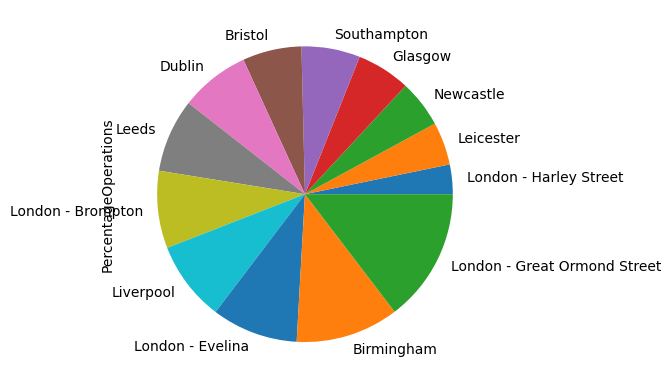

In [37]:
child_heart.set_index('Hospital').PercentageOperations.plot.pie()

In [38]:
# Creating a base chart with a title, aligned to the left and with normal font weight
base = alt.Chart(
    child_heart,
    title = alt.TitleParams(r"Habilitação", anchor = 'start', fontWeight = 'normal')
).encode(
    theta = alt.Theta("PercentageOperations:Q", stack = True), # Encoding the angle (theta) for the pie chart
    color = alt.Color('Hospital'), # Encoding color based on the 'Tier' field
    #order = alt.Order(field = 'Discipĺina') # Ordering the sectors of the pie chart based on the 'Tier' field
)

# Creating the pie chart with an outer radius of 115
pie = base.mark_arc(outerRadius = 115)

# Creating text labels for each sector of the pie chart
text = base.mark_text(radius = 140, size = 15).encode(text = alt.Text("PercentageOperations:Q"))

# Combining the pie chart and text labels
acc_pie = pie + text
acc_pie

alt.LayerChart(...)

#### Gráfico de barras

In [39]:
# Creating a vertical bar chart
vert_bar = alt.Chart(
    child_heart,
    #title = alt.TitleParams('Hospital', fontSize = 20, anchor='start')  # Adding a title with specific font size
).mark_bar(color='#888888').encode(
    x = alt.X(
        'PercentageOperations:Q',
        axis = alt.Axis(
            title = "Porcentagem das operações realizadas em 2012-15 por hospital",  # Setting a custom title for the y-axis
            grid = True,  # Turning off grid lines
        )
    ),
    y = alt.Y(
        'Hospital:N',
        axis=alt.Axis(labelAngle=0, ticks = False),
        sort=None,
        title=None
    )
).properties(
    width = 500 ,  height = 500 # Setting the width of the chart
).configure_view(stroke = None).configure_scale(bandPaddingInner=0.4)

vert_bar

alt.Chart(...)

## Base assassino Shipman

A partir das variáveis qualitativas, explore visualmente o que elas podem informar para a resolução do caso.

In [4]:
shipman_victims = pd.read_csv(f'00-1-shipman-confirmed-victims-x.csv')

In [5]:
shipman_victims

,DateofDeath,Name,Age,PlaceofDeath,Decision,yearOfDeath,gender,fractionalDeathYear,ageBracket,gender2
0,17-Mar-75,Eva Lyons,70,Own home,Unlawful killing,1975,0,1974.71,70-74,Women
1,07-Aug-78,Sarah Hannah Marsland,86,Own home,Unlawful killing,1978,0,1978.10,85-89,Women
2,30-Aug-78,Mary Ellen Jordan,73,Own home,Unlawful killing,1978,0,1978.16,70-74,Women
3,07-Dec-78,Harold Bramwell,73,Own home,Unlawful killing,1978,1,1978.44,70-74,Men
4,20-Dec-78,Annie Campbell,88,Own home,Unlawful killing,1978,0,1978.47,85-89,Women
...,...,...,...,...,...,...,...,...,...,...
210,20-Mar-98,Ada Warburton,77,Own home,Unlawful killing,1998,0,1997.72,75-79,Women
211,24-Mar-98,Martha Marley,88,Own home,Unlawful killing,1998,0,1997.73,85-89,Women
212,11-May-98,Winifred Mellor,73,Own home,Conviction,1998,0,1997.86,70-74,Women
213,12-Jun-98,Joan May Melia,73,Own home,Conviction,1998,0,1997.95,70-74,Women


In [7]:
alt.Chart(shipman_victims).mark_arc().encode(
    theta = "count()",
    color = alt.Color('gender2'),
    tooltip = ['gender2:N', 'count():Q']
)

alt.Chart(...)

In [15]:
# Creating a vertical bar chart
vert_bar = alt.Chart(
    shipman_victims
).mark_bar().encode(
    y = alt.Y(
        'PlaceofDeath:N',
        axis = alt.Axis(
            title = "Taxa de sobrevivência em 30 dias (%)",  # Setting a custom title for the y-axis
            grid = True,  # Turning off grid lines
        ),
        sort='-x'
    ),
    x = alt.X(
        'count()',
        axis=alt.Axis(labelAngle=0, ticks = False),
    )
).properties(
    width = 500,  height = 300  # Setting the width of the chart
).configure_view(stroke = None)

vert_bar

alt.Chart(...)